# Bollinger Band Rule on a Dynamic Spread

This notebook turns the Section 3.1 dynamic price spread into a bounded Bollinger-band strategy.

The comparison is between:

- a linear rule that sizes continuously as negative Z-score;
- a Bollinger rule that holds only -1, 0, or +1 unit of the spread.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.float_format", lambda x: f"{x:,.6f}")


def find_repo_root(start: Path | None = None) -> Path:
    current = Path.cwd() if start is None else start.resolve()
    for candidate in (current, *current.parents):
        if (candidate / "fixtures/crypto/crypto_daily_close.csv").exists():
            return candidate
    raise FileNotFoundError(
        "Missing shared crypto fixture: fixtures/crypto/crypto_daily_close.csv. "
        "Run `python3 scripts/python/download-crypto-fixtures.py --source binance-monthly-archive` "
        "from the repository root."
    )


repo_root = find_repo_root()
close = pd.read_csv(
    repo_root / "fixtures/crypto/crypto_daily_close.csv",
    parse_dates=["date"],
).set_index("date").sort_index()
close = close.apply(pd.to_numeric, errors="coerce").dropna(how="all")

symbols = ["BTCUSDT", "ETHUSDT"]
missing = [symbol for symbol in symbols if symbol not in close]
if missing:
    raise ValueError(f"Fixture is missing required symbols: {missing}")

prices = close[symbols].dropna()
prices.tail()


,BTCUSDT,ETHUSDT
date,,
2024-12-27,"94,299.030000","3,333.510000"
2024-12-28,"95,300.000000","3,404.000000"
2024-12-29,"93,738.200000","3,356.480000"
2024-12-30,"92,792.050000","3,361.840000"
2024-12-31,"93,576.000000","3,337.780000"


In [2]:
def rolling_hedge_ratio(y: pd.Series, x: pd.Series, lookback: int) -> pd.Series:
    beta = pd.Series(np.nan, index=y.index, name="hedge_ratio")
    for t in range(lookback - 1, len(y)):
        y_window = y.iloc[t - lookback + 1 : t + 1].to_numpy()
        x_window = x.iloc[t - lookback + 1 : t + 1].to_numpy()
        design = np.column_stack([x_window, np.ones(lookback)])
        beta.iloc[t] = np.linalg.lstsq(design, y_window, rcond=None)[0][0]
    return beta


def zscore(series: pd.Series, lookback: int) -> pd.Series:
    mean = series.rolling(lookback).mean()
    std = series.rolling(lookback).std()
    return (series - mean) / std


def strategy_returns(prices: pd.DataFrame, hedge_ratio: pd.Series, units: pd.Series) -> pd.Series:
    aligned = pd.concat([prices, hedge_ratio.rename("hedge_ratio"), units.rename("units")], axis=1).dropna()
    btc = aligned["BTCUSDT"]
    eth = aligned["ETHUSDT"]
    shares = pd.DataFrame(
        {
            "BTCUSDT": -aligned["hedge_ratio"] * aligned["units"],
            "ETHUSDT": aligned["units"],
        },
        index=aligned.index,
    )
    dollar_positions = shares.mul(aligned[["BTCUSDT", "ETHUSDT"]])
    pnl = (dollar_positions.shift(1) * aligned[["BTCUSDT", "ETHUSDT"]].pct_change()).sum(axis=1)
    gross = dollar_positions.shift(1).abs().sum(axis=1)
    return (pnl / gross).replace([np.inf, -np.inf], np.nan).dropna()


def performance_stats(returns: pd.Series) -> pd.Series:
    returns = returns.dropna()
    if returns.empty or returns.std() == 0:
        return pd.Series({"days": len(returns), "APR": np.nan, "Sharpe": np.nan, "max_drawdown": np.nan})
    equity = (1 + returns).cumprod()
    drawdown = equity / equity.cummax() - 1
    return pd.Series(
        {
            "days": len(returns),
            "APR": equity.iloc[-1] ** (252 / len(returns)) - 1,
            "Sharpe": np.sqrt(252) * returns.mean() / returns.std(),
            "max_drawdown": drawdown.min(),
        }
    )

def fill_positions(entry_long, exit_long, entry_short, exit_short) -> pd.Series:
    position = []
    current = 0
    for long_in, long_out, short_in, short_out in zip(entry_long, exit_long, entry_short, exit_short):
        if current == 1 and long_out:
            current = 0
        if current == -1 and short_out:
            current = 0
        if current == 0 and long_in:
            current = 1
        if current == 0 and short_in:
            current = -1
        position.append(current)
    return pd.Series(position, index=entry_long.index, name="units")


In [3]:
lookback = 20
entry_zscore = 1.0
exit_zscore = 0.0

x = prices["BTCUSDT"]
y = prices["ETHUSDT"]
hedge_ratio = rolling_hedge_ratio(y, x, lookback)
yport = (y - hedge_ratio * x).rename("portfolio_price")
z = zscore(yport, lookback).rename("zscore")

pd.concat([hedge_ratio, yport, z], axis=1).dropna().tail()


,hedge_ratio,portfolio_price,zscore
date,,,
2024-12-27,0.061415,"-2,457.846142",-0.687740
2024-12-28,0.059172,"-2,235.059290",-0.581255
2024-12-29,0.059303,"-2,202.446296",-0.596830
2024-12-30,0.057993,"-2,019.434389",-0.407168
2024-12-31,0.056291,"-1,929.726337",-0.329814


In [4]:
linear_units = (-z).rename("units")
linear_returns = strategy_returns(prices, hedge_ratio, linear_units)

longs_entry = z < -entry_zscore
longs_exit = z >= -exit_zscore
shorts_entry = z > entry_zscore
shorts_exit = z <= exit_zscore
bollinger_units = fill_positions(longs_entry.fillna(False), longs_exit.fillna(False), shorts_entry.fillna(False), shorts_exit.fillna(False))
bollinger_returns = strategy_returns(prices, hedge_ratio, bollinger_units)

pd.DataFrame(
    {
        "linear_zscore": performance_stats(linear_returns),
        "bounded_bollinger": performance_stats(bollinger_returns),
    }
).T


,days,APR,Sharpe,max_drawdown
linear_zscore,327.000000,-0.259045,-1.286088,-0.385042
bounded_bollinger,271.000000,-0.311743,-1.549997,-0.350900


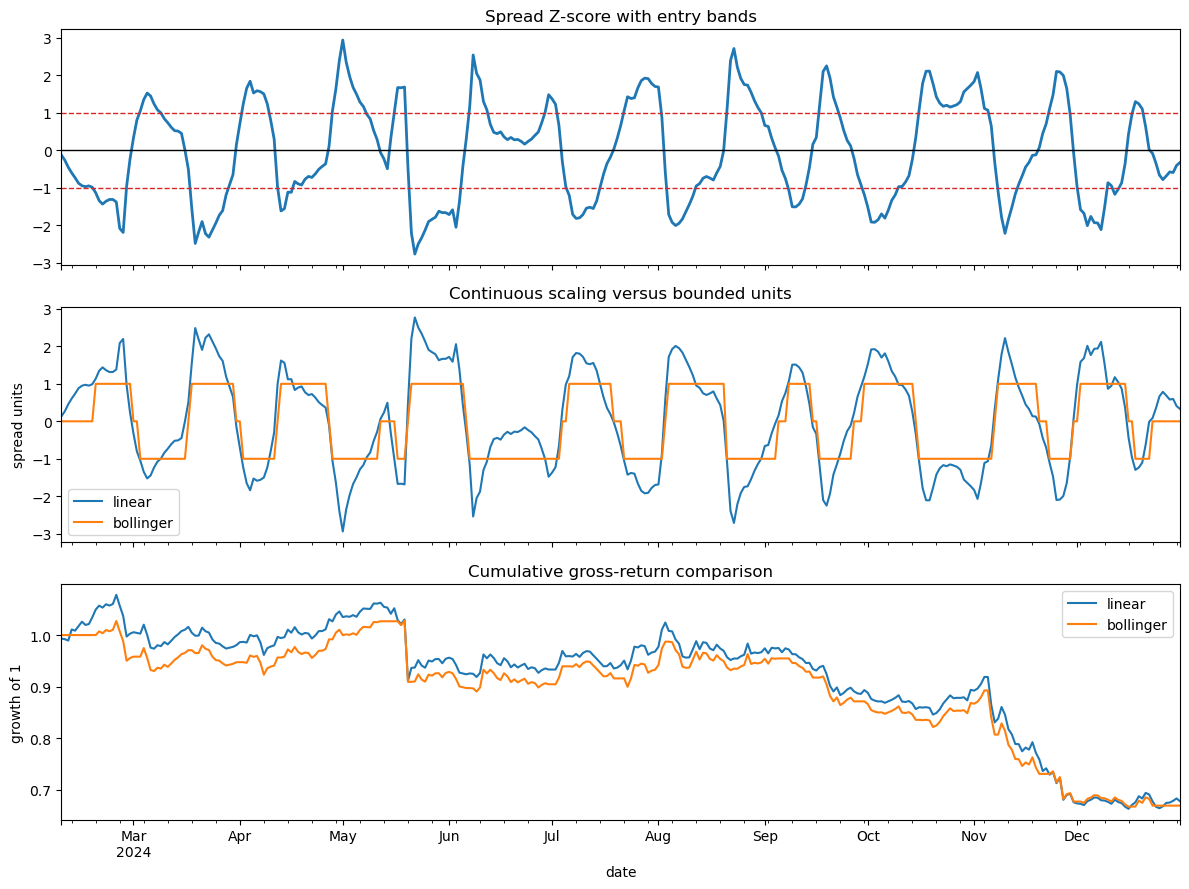

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

z.plot(ax=axes[0], color="tab:blue", linewidth=2)
axes[0].axhline(entry_zscore, color="tab:red", linestyle="--", linewidth=1)
axes[0].axhline(-entry_zscore, color="tab:red", linestyle="--", linewidth=1)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Spread Z-score with entry bands")

pd.concat({"linear": linear_units, "bollinger": bollinger_units}, axis=1).plot(ax=axes[1], linewidth=1.5)
axes[1].set_title("Continuous scaling versus bounded units")
axes[1].set_ylabel("spread units")

(1 + pd.concat({"linear": linear_returns, "bollinger": bollinger_returns}, axis=1).fillna(0)).cumprod().plot(ax=axes[2])
axes[2].set_title("Cumulative gross-return comparison")
axes[2].set_ylabel("growth of 1")

plt.tight_layout();


In [6]:
pd.Series(
    {
        "long_entries": int(longs_entry.sum()),
        "short_entries": int(shorts_entry.sum()),
        "days_in_market": int((bollinger_units != 0).sum()),
        "max_abs_linear_units": float(linear_units.abs().max()),
        "max_abs_bollinger_units": float(bollinger_units.abs().max()),
    }
)


long_entries               87.000000
short_entries              94.000000
days_in_market            271.000000
max_abs_linear_units        2.937806
max_abs_bollinger_units     1.000000
dtype: float64

## Interpretation

The Bollinger rule keeps the same Z-score as the linear rule, but changes the position map. This makes the capital budget explicit: one long unit, one short unit, or no position.
